In [1]:
import numpy as np
import pandas as pd

from utils.plot import plot_conjuntos_fuzzy
from utils.pertinencias import pertinencia_trapezoidal, pertinencia_triangular

# Trabalho 1

## Carregar dados e montar universos de discursos

In [2]:
coletas_df = pd.read_csv("../data/coletas.csv")
coletas_df.head()

,coleta,velocidade_vento,umidade_relativa,vibracao_torre
0,1,5.2,18,0.8
1,2,7.5,35,1.9
2,3,10.8,42,3.2
3,4,13.6,58,4.5
4,5,15.4,67,5.1


In [3]:
universos_discurso = {
    'velocidade_vento': np.arange(0, 35.1, 0.1),          # de 0 a 35 m/s
    'umidade_relativa': np.arange(0, 101, 1),           # de 0 a 100%
    'vibracao_torre': np.arange(0, 10.1, 0.1)             # de 0 a 10 mm/s
}

print("Universos de discurso:")
for var, universo in universos_discurso.items():
    print(f"{var}: {universo[0]} a {universo[-1]} (passo {universo[1] - universo[0]})")

Universos de discurso:
velocidade_vento: 0.0 a 35.0 (passo 0.1)
umidade_relativa: 0 a 100 (passo 1)
vibracao_torre: 0.0 a 10.0 (passo 0.1)


## Fuzzyficação

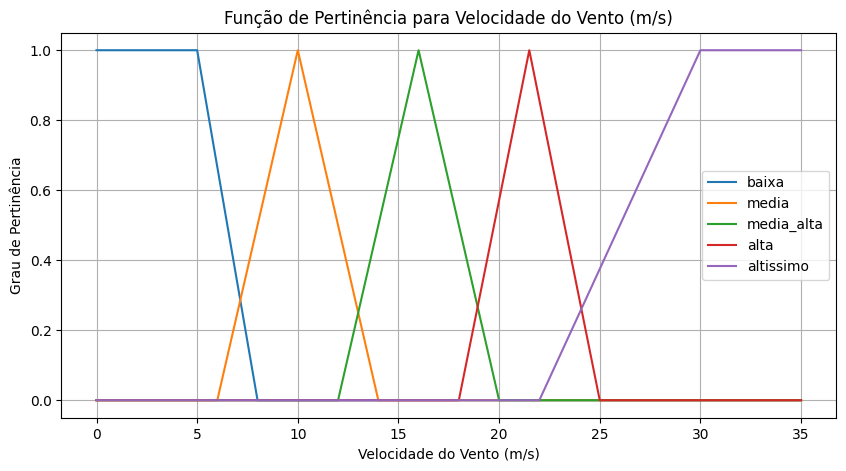

In [4]:

conjuntos_fuzzy_velocidade_vento = {
    'baixa': pertinencia_trapezoidal(universos_discurso['velocidade_vento'], 0, 0, 5, 8),
    'media': pertinencia_triangular(universos_discurso['velocidade_vento'], 6, 10, 14),
    'media_alta': pertinencia_triangular(universos_discurso['velocidade_vento'], 12, 16, 20),
    'alta': pertinencia_triangular(universos_discurso['velocidade_vento'], 18, 21.5, 25),
    'altissimo': pertinencia_trapezoidal(universos_discurso['velocidade_vento'], 22, 30, 40, 40)
}

plot_conjuntos_fuzzy(universos_discurso['velocidade_vento'], 'Velocidade do Vento (m/s)', conjuntos_fuzzy_velocidade_vento,
                     xlabel='Velocidade do Vento (m/s)')

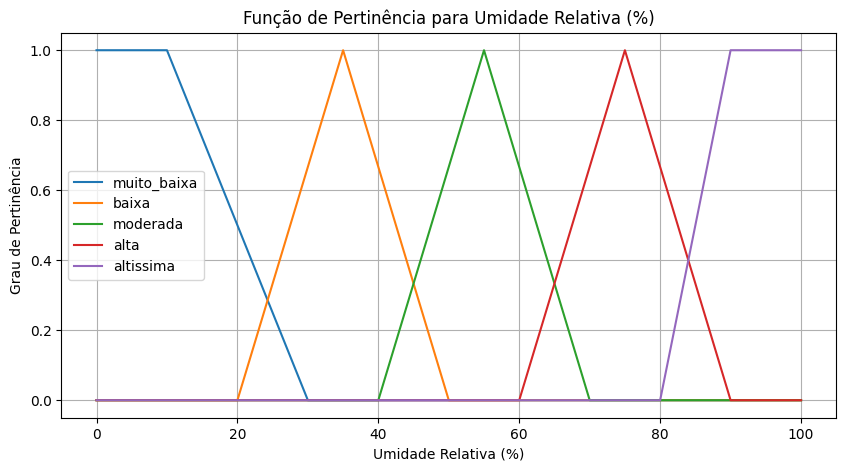

In [5]:
conjuntos_fuzzy_umidade = {
    'muito_baixa': pertinencia_trapezoidal(universos_discurso['umidade_relativa'], 0, 0, 10, 30),
    'baixa': pertinencia_triangular(universos_discurso['umidade_relativa'], 20, 35, 50),
    'moderada': pertinencia_triangular(universos_discurso['umidade_relativa'], 40, 55, 70),
    'alta': pertinencia_triangular(universos_discurso['umidade_relativa'], 60, 75, 90),
    'altissima': pertinencia_trapezoidal(universos_discurso['umidade_relativa'], 80, 90, 100, 100)
}

plot_conjuntos_fuzzy(universos_discurso['umidade_relativa'], 'Umidade Relativa (%)', conjuntos_fuzzy_umidade,
                     xlabel='Umidade Relativa (%)')

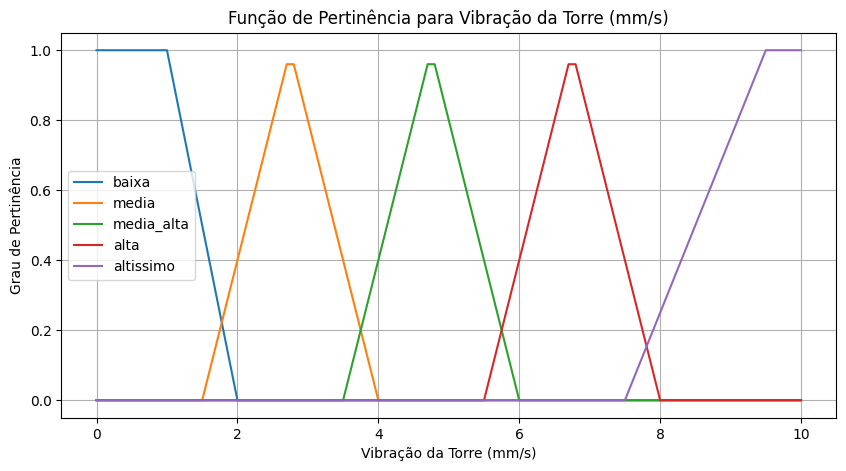

In [ ]:
conjuntos_fuzzy_vibracao = {
    'baixa': pertinencia_trapezoidal(universos_discurso['vibracao_torre'], 0, 0, 1, 2),
    'media': pertinencia_triangular(universos_discurso['vibracao_torre'], 1.5, 2.75, 4),
    'media_alta': pertinencia_triangular(universos_discurso['vibracao_torre'], 3.5, 4.75, 6),
    'alta': pertinencia_triangular(universos_discurso['vibracao_torre'], 5.5, 6.75, 8),
    'altissimo': pertinencia_trapezoidal(universos_discurso['vibracao_torre'], 7.5, 9.5, 15, 15)
}

plot_conjuntos_fuzzy(universos_discurso['vibracao_torre'], 'Vibração da Torre (mm/s)', conjuntos_fuzzy_vibracao,
                     xlabel='Vibração da Torre (mm/s)')

## Regras